# Ionosphere - classificazione supervisionata

Il dataset UCI Ionosphere contiene misurazioni radar della ionosfera. 
Ogni osservazione è descritta da 34 attributi numerici ottenuti dall'elaborazione dei segnali radar tramite una funzione di autocorrelazione. Il file non fornisce nomi specifici per le singole feature, quindi per comodità le ho chiamate attr_1, attr_2, ..., attr_34.

L'obiettivo e' classificare i ritorni radar in due classi:

- `g`: good;
- `b`: bad.

La consegna richiede una minima analisi esplorativa, l'uso di piu' modelli, lo
studio di alcuni parametri e una comparazione finale dei risultati.

## Import delle librerie

In [5]:
import warnings # warnings per nascondere alcuni avvisi tecnici che non cambiano il risultato.
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

## Caricamento del dataset

In [6]:
# Il file ionosphere.data si trova nella stessa cartella del notebook.
data_path = Path("ionosphere.data")

feature_cols = [f"attr_{i}" for i in range(1, 35)] # le prime 34 colonne sono attributi numerici, l'ultima e' la classe.


data = pd.read_csv(data_path, header=None)
data.columns = feature_cols + ["class"]

print("File dati:", data_path)
print("Dimensione dataframe:", data.shape)
data.head()

File dati: ionosphere.data
Dimensione dataframe: (351, 35)


,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,attr_10,...,attr_26,attr_27,attr_28,attr_29,attr_30,attr_31,attr_32,attr_33,attr_34,class
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


## Analisi esplorativa minima

In [7]:

X = data[feature_cols].to_numpy(dtype=float) # X matrice che contiene le feature quindi le variabili usate per predire.
#così prendo la colonna "class" e la trasformo in un array numpy, che contiene le classi vere di ogni esempio: b oppure g.

y = data["class"].to_numpy() # y contiene la classe vera di ogni esempio: b oppure g.
classes = np.array(["b", "g"])

print("Numero di esempi:", X.shape[0])
print("Numero di feature:", X.shape[1])
print("Classi:", set(y))

# controllo se ci sono valori mancanti.
print("Missing values:", data.isna().sum().sum())

# controllo se il dataset e' bilanciato oppure no.
class_counts = data["class"].value_counts().reindex(classes)
print("Distribuzione classi")  #VEDIAMO COSì LE OSSERVAZIONI TOTALI PER OGNI CLASSE
print(class_counts)

# cerco eventuali feature costanti.
# anche perché una feature costante ha sempre lo stesso valore, quindi non aiuta a distinguere b e g.
constant_features = []
for col in feature_cols:
    if data[col].nunique() == 1:
        constant_features.append(col)

print("Feature costanti:", constant_features)

Numero di esempi: 351
Numero di feature: 34
Classi: {'b', 'g'}
Missing values: 0
Distribuzione classi
class
b    126
g    225
Name: count, dtype: int64
Feature costanti: ['attr_2']


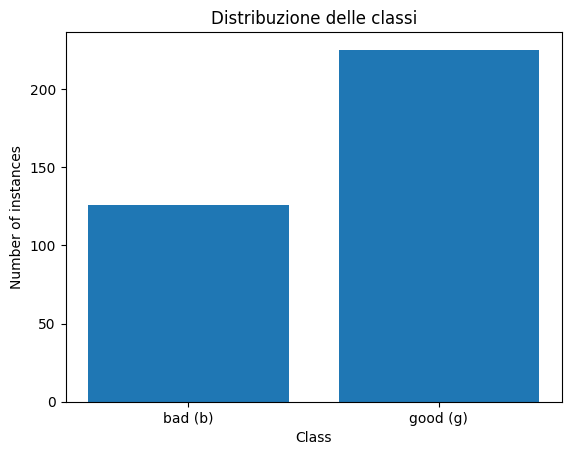

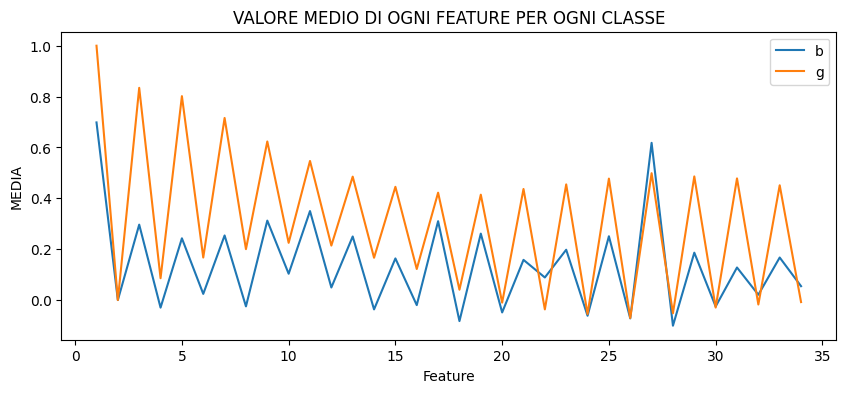

In [8]:
# grafico semplice per vedere quante osservazioni ci sono per ogni classe.
plt.figure()
plt.title("Distribuzione delle classi")
plt.bar(["bad (b)", "good (g)"], class_counts.values)
plt.xlabel("Class")
plt.ylabel("Number of instances")
plt.show()

# qui confronto e mostro il valore medio di ogni feature nelle due classi.
# con curve sono diverse, implica che alcune feature possono aiutare la classificazione.
means = data.groupby("class")[feature_cols].mean().T

plt.figure(figsize=(10, 4))
plt.title("VALORE MEDIO DI OGNI FEATURE PER OGNI CLASSE")
plt.plot(range(1, 35), means["b"], label="b")
plt.plot(range(1, 35), means["g"], label="g")
plt.xlabel("Feature")
plt.ylabel("MEDIA")
plt.legend()
plt.show()

Dal grafico delle distribuzioni delle classi, si vede che la classe `g` è più numerosa della classe `b`.
Il dataset quindi non è perfettamente bilanciato. Per questo motivo, nella
valutazione dei modelli, è utile usare una cross-validation stratificata, in modo
da mantenere una proporzione simile delle classi nei diversi fold.

Il secondo grafico invece mostra il valore medio delle feature per le due classi. Si nota che
per diverse feature le due curve hanno valori differenti: questo suggerisce che
alcuni attributi contengono informazione utile per distinguere la classe `g`
dalla classe `b`. Le feature però non separano le classi in modo banale, quindi
è necessario confrontare più modelli di classificazione.

## Rimozione della feature costante

In [9]:
# attr_2 e' costante, quindi non aiuta a separare le classi.
# lo elimino in modo esplicito, cosi' il passaggio e' chiaro.
data_clean = data.drop(columns=constant_features)
feature_cols = [col for col in feature_cols if col not in constant_features]

# ricreo X usando il dataframe pulito.
X = data_clean[feature_cols].to_numpy(dtype=float) #ricordo che contiene solo feature
y = data_clean["class"].to_numpy()  #ricordo che contiene solo la classe vera di ogni esempio

print("Nuova dimensione di X:", X.shape)  #spunta il numero di osservazioni e il numero di feature con uno in meno perché l'abbiamo tolto

Nuova dimensione di X: (351, 33)


## PCA per visualizzare i dati

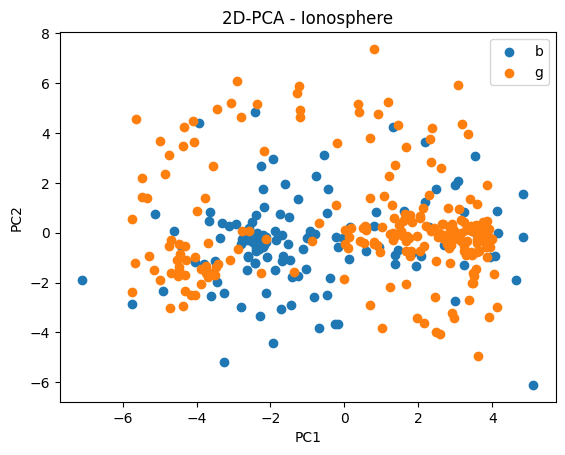

Varianza spiegata: [0.26703461 0.12844377]


In [10]:
# prima della PCA standardizzo le feature.
# così evito che una variabile pesi piu' delle altre solo per la scala numerica.
# invece per i modelli la standardizzazione viene rifatta dentro ogni fold.
scaler = StandardScaler() #creo oggetto per standardizzazione, cosi' tutte le feature hanno media 0 e varianza 1.
 #tutte feature sulla stessa scala, media 0 e varianza 1
X_scaled = scaler.fit_transform(X) #calcola media e deviazione standard


pca = PCA(n_components=2) # come già sappiamo la PCA riduce i dati a 2 componenti, cosi' posso fare un grafico 2D.
xt = pca.fit_transform(X_scaled) #trasfroma ogni osservazione in un punto nello spazio 2D, quindi xt e' una matrice con 2 colonne e tante righe quante osservazioni.

plt.figure()
plt.title("2D-PCA - Ionosphere")
plt.scatter(xt[y == "b", 0], xt[y == "b", 1], label="b") #prende esempi che hanno b, e prende prima componente (0) e poi seconda componente (1) e li mette in un grafico a dispersione
plt.scatter(xt[y == "g", 0], xt[y == "g", 1], label="g")  #//
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

print("Varianza spiegata:", pca.explained_variance_ratio_)

La PCA permette di proiettare i dati in due dimensioni, così da visualizzarli
meglio. Dal grafico si nota che le due classi non risultano completamente
separate nel piano delle prime due componenti principali. Questo suggerisce che
il problema non è immediatamente separabile in modo semplice, almeno in questa
rappresentazione 2D.

## Funzione per valutare i modelli

In [ ]:
# uso 5 fold stratificati.
# StratifiedKFold mantiene circa la stessa proporzione di classi in ogni fold.
nfolds = 5
skf = StratifiedKFold(n_splits=nfolds, shuffle=True, random_state=42)

# qui salvo i risultati dei vari modelli.
results = []

# e qui salvo le matrici di confusione medie.
cms = {}

def valuta_modello(model_name, param_name, param_value, clf):
    accuracies = [] #(TP+TN)/(TP+TN+FP+FN) quindi la percentuale di predizioni corrette sul totale delle predizioni
    precisions = []
    recalls = []
    cm_media = np.zeros((2, 2)) #perche ci sono 2 classi, quindi la matrice di confusione e' 2x2. Inizializzo a zero, poi sommo le matrici di confusione dei vari fold e alla fine divido per nfolds per avere la media.

    # per ogni giro del for usa una parte dei dati per training e una per test.
    for f, (train_index, test_index) in enumerate(skf.split(X, y), start=1):  #Restituisce, per ogni fold, due insiemi di indici train_index e test_index, che indicano quali esempi usare per il training e quali per il test.
        x_train = X[train_index] #Gli indici sono le posizioni delle righe del dataset.
        y_train = y[train_index] #x input e y output 
        x_test = X[test_index]
        y_test = y[test_index]

        # Standardizzo usando SOLO il training fold.
        # e poi applico la stessa trasformazione al test fold.
        # cosi' evito di usare informazioni del test durante il training.
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)
        x_test = scaler.transform(x_test)

        # addestro il modello e faccio le predizioni.
        with warnings.catch_warnings(): #nascondendo alcuni warning che non cambiano il risultato
            warnings.simplefilter("ignore")
            clf.fit(x_train, y_train)
            y_pred = clf.predict(x_test)

        # calcolo l'accuracy, precisione e richiamo del fold.
        acc = accuracy_score(y_test, y_pred, normalize=True)

        # uso average="macro" perché considera entrambe le classi allo stesso modo.
        precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
        recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

        accuracies.append(acc)
        precisions.append(precision)
        recalls.append(recall)

        # calcolo la matrice di confusione normalizzata.
        cm = confusion_matrix(y_test, y_pred, labels=classes, normalize="true")

        # ora faccio la media delle matrici sui fold.
        cm_media = cm_media + cm / nfolds

    accuracies = np.array(accuracies)
    precisions = np.array(precisions)
    recalls = np.array(recalls)

    # infine salvo accuracy media, deviazione standard e accuracy di ogni fold.
    results.append({
        "model": model_name,
        "param_name": param_name,
        "param_value": str(param_value),
        "mean_accuracy": np.mean(accuracies),
        "std_accuracy": np.std(accuracies),
        "mean_precision": np.mean(precisions),
        "mean_recall": np.mean(recalls),
        "fold_1": accuracies[0],
        "fold_2": accuracies[1],
        "fold_3": accuracies[2],
        "fold_4": accuracies[3],
        "fold_5": accuracies[4],
    })

    cms[(model_name, param_name, str(param_value))] = cm_media  #matrice di confusione media per questo modello e questo parametro

## Regressione logistica

In [12]:
# provo la regressione logistica con diversi valori di C.
# C controlla la regolarizzazione: valori diversi possono cambiare le performance.
for c in [0.01, 0.1, 1, 10, 100]:
    clf = LogisticRegression(C=c, max_iter=2000, random_state=42)
    valuta_modello("Logistic Regression", "C", c, clf)

## LDA e QDA

In [ ]:
# qui provo LDA senza shrinkage.
clf = LinearDiscriminantAnalysis()
valuta_modello("LDA", "shrinkage", "none", clf)

# qui provo LDA con shrinkage automatico. la regolartizzazione della matrice di covarianza
# aiuta a migliorare le performance del modello, soprattutto
# per rendere il modello piu' stabile quando le feature sono correlate.
clf = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
valuta_modello("LDA", "shrinkage", "auto", clf)

# QDA viene provata con diversi valori di regolarizzazione.
for reg_param in [0.01, 0.05, 0.1, 0.2, 0.5, 0.8]:  # il parametro reg_param aiuta quando la matrice di covarianza e' problematica.
    clf = QuadraticDiscriminantAnalysis(reg_param=reg_param)
    valuta_modello("QDA", "reg_param", reg_param, clf)

## SVM

In [14]:
# prima studio quale kernel SVM funziona meglio.
kernels = ["linear", "rbf", "poly", "sigmoid"]

for kernel in kernels:
    clf = SVC(kernel=kernel, C=1, gamma="scale")
    valuta_modello("SVM", "kernel", kernel, clf)

# e poi dal confronto dei kernel, rbf e' quello piu' interessante.
# quindi studio anche il parametro C usando kernel rbf.
for c in [0.1, 1, 10, 100]:
    clf = SVC(kernel="rbf", C=c, gamma="scale")
    valuta_modello("SVM rbf", "C", c, clf)

## Perceptron

In [ ]:
# provo il perceptron con diversi valori di eta0.
# eta0 e' il passo di apprendimento.
for eta0 in [0.001, 0.01, 0.1, 1]:  #eta0 dice quanto il modello deve fare gli aggiustamenti dei pesi ad ogni iterazione. Valori troppo piccoli possono far impiegare troppo tempo al modello per convergere, mentre valori troppo grandi possono farlo oscillare e non convergere.
    clf = Perceptron(max_iter=1000, eta0=eta0, random_state=42)
    valuta_modello("Perceptron", "eta0", eta0, clf)

## Tabella dei risultati

In [16]:
# trasformo la lista dei risultati in un dataframe.
result_df = pd.DataFrame(results)

# ordino dal modello migliore al peggiore.
result_df = result_df.sort_values(["mean_accuracy", "std_accuracy"], ascending=[False, True])
result_df = result_df.reset_index(drop=True)
#deviazione standard std_accuracy piu' bassa = modello piu' stabile
# mostro le prime 10 configurazioni.
result_df.head(10)

,model,param_name,param_value,mean_accuracy,std_accuracy,mean_precision,mean_recall,fold_1,fold_2,fold_3,fold_4,fold_5
0,SVM rbf,C,10,0.943058,0.020064,0.947833,0.929658,0.929577,0.942857,0.957143,0.971429,0.914286
1,QDA,reg_param,0.05,0.942978,0.012914,0.949912,0.927573,0.957746,0.942857,0.928571,0.928571,0.957143
2,SVM,kernel,rbf,0.940121,0.024663,0.946909,0.923573,0.957746,0.942857,0.900000,0.971429,0.928571
3,SVM rbf,C,1,0.940121,0.024663,0.946909,0.923573,0.957746,0.942857,0.900000,0.971429,0.928571
4,QDA,reg_param,0.1,0.934447,0.014667,0.945477,0.913949,0.943662,0.957143,0.928571,0.914286,0.928571
5,SVM rbf,C,100,0.934406,0.026601,0.938395,0.920906,0.957746,0.942857,0.928571,0.957143,0.885714
6,SVM rbf,C,0.1,0.931630,0.018926,0.943512,0.910103,0.929577,0.900000,0.928571,0.957143,0.942857
7,QDA,reg_param,0.8,0.923018,0.017333,0.939943,0.896171,0.943662,0.900000,0.914286,0.942857,0.914286
8,QDA,reg_param,0.2,0.920241,0.006816,0.941505,0.890701,0.915493,0.914286,0.914286,0.928571,0.928571
9,QDA,reg_param,0.5,0.903139,0.016621,0.934578,0.865077,0.901408,0.914286,0.871429,0.914286,0.914286


Oltre all'accuracy, sono state calcolate anche precision e recall, perché il
dataset non è perfettamente bilanciato. L'accuracy misura la percentuale totale
di classificazioni corrette, mentre precision e recall permettono di osservare
meglio il comportamento del modello sulle singole classi.

La precision indica quanto sono affidabili le predizioni del modello per una
classe; la recall indica quanti esempi reali di quella classe vengono riconosciuti
correttamente. Sono state usate con media macro (`average="macro"`), quindi le
metriche vengono calcolate separatamente per `b` e `g` e poi mediate dando lo
stesso peso a entrambe le classi.

## Miglior modello per famiglia

                 model param_name param_value  mean_accuracy  std_accuracy  \
0              SVM rbf          C          10       0.943058      0.020064   
1                  QDA  reg_param        0.05       0.942978      0.012914   
2                  SVM     kernel         rbf       0.940121      0.024663   
3  Logistic Regression          C          10       0.891590      0.048491   
4                  LDA  shrinkage        auto       0.868813      0.044879   
5           Perceptron       eta0         0.1       0.868773      0.039068   

   mean_precision  mean_recall  
0        0.947833     0.929658  
1        0.949912     0.927573  
2        0.946909     0.923573  
3        0.896668     0.866239  
4        0.893895     0.825812  
5        0.872436     0.845060  


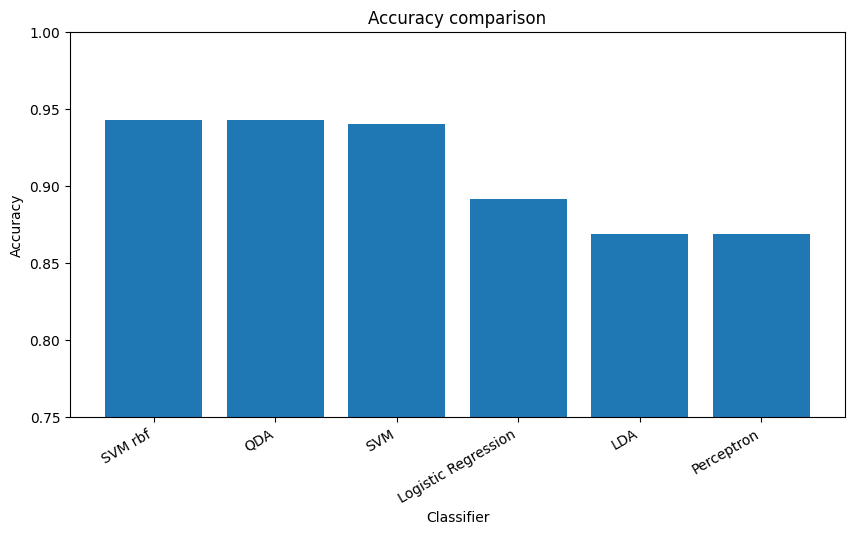

In [17]:
# per ogni famiglia di modelli prendo solo la configurazione migliore.
best_by_model = (
    result_df.sort_values(["model", "mean_accuracy", "std_accuracy"], ascending=[True, False, True])
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("mean_accuracy", ascending=False)
)
best_by_model = best_by_model.reset_index(drop=True)
print(best_by_model[[
    "model",
    "param_name",
    "param_value",
    "mean_accuracy",
    "std_accuracy",
    "mean_precision",
    "mean_recall"
]])
# grafico finale di confronto
plt.figure(figsize=(10, 5))
plt.title("Accuracy comparison")
plt.bar(best_by_model["model"], best_by_model["mean_accuracy"])
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.ylim(0.75, 1.0)
plt.xticks(rotation=30, ha="right")
plt.show()

Il grafico confronta l'accuracy media dei migliori modelli di ogni famiglia.
Si vede che SVM con kernel RBF e QDA regolarizzato ottengono le prestazioni
migliori. I modelli lineari, come regressione logistica, LDA e perceptron,
risultano invece meno accurati.

## Stabilità sui fold

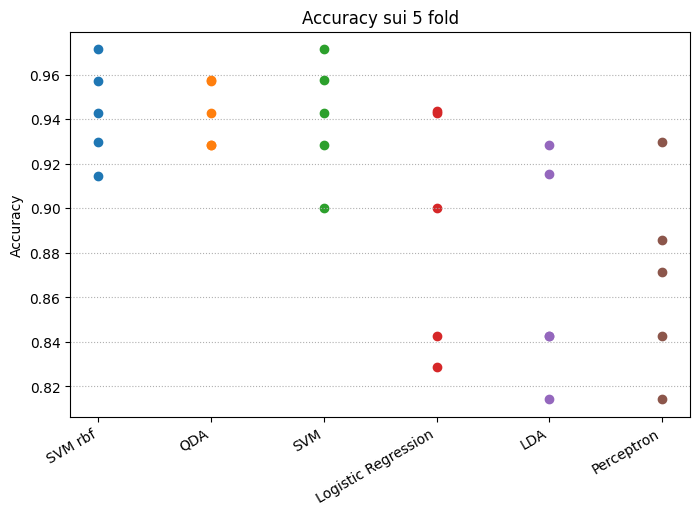

In [ ]:
best_names = best_by_model["model"].values

plt.figure(figsize=(8, 5))
plt.title("Accuracy sui 5 fold")

for i, row in enumerate(best_by_model.to_dict("records")):
    accurancies = [
        row["fold_1"],
        row["fold_2"],
        row["fold_3"],
        row["fold_4"],
        row["fold_5"],
    ] #5 accurancies per ogni modello, una per ogni fold. quindi vediamo la distribuzione delle accuracy sui fold per ogni modello.
    plt.scatter([i+1]*5, accurancies) #disegna 5 punti verticali per ogni modello, uno per ogni fold, quindi vediamo la distribuzione delle accuracy sui fold per ogni modello.

plt.xticks(range(1, len(best_names)+1), best_names, rotation=30, ha="right") #scrive nomi asse x
plt.ylabel("Accuracy")
plt.grid(axis="y", linestyle=":")
plt.show()

Questo grafico mostra le accuracy ottenute nei 5 fold per i migliori modelli.
Ogni punto rappresenta l'accuracy di un fold. Se i punti sono vicini tra loro,
il modello è più stabile; se sono più sparsi, le prestazioni variano di più tra
i fold. Dal grafico si vede che SVM RBF e QDA hanno risultati molto vicini, ma
QDA varia leggermente meno tra i fold.

Più i punti sono sparsi, più è alta la deviazione standard. 

## Effetto dei parametri

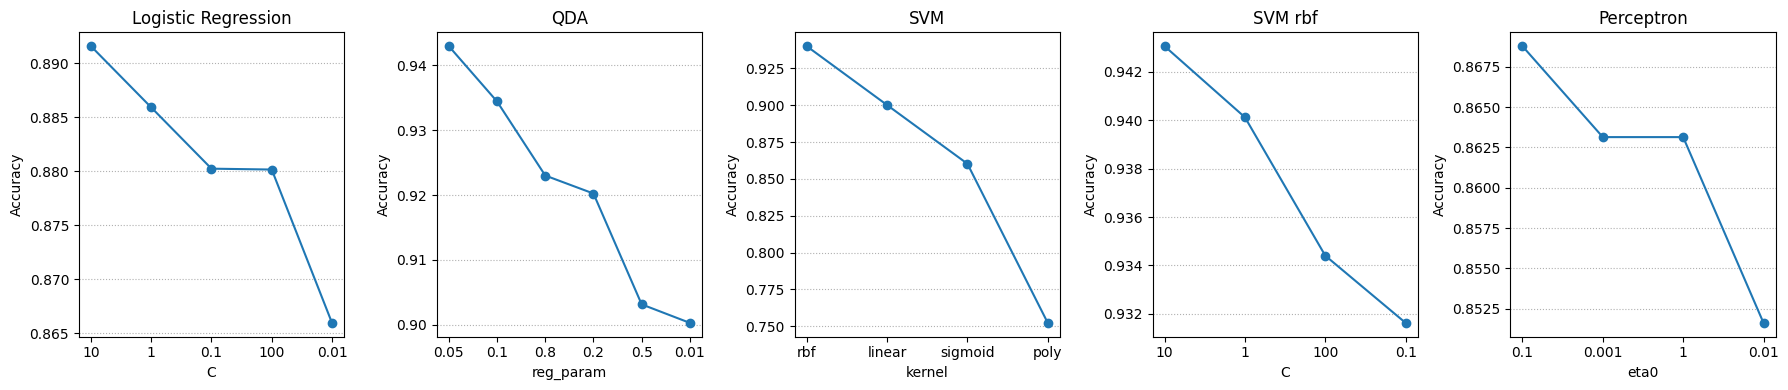

In [ ]:
# qui guardo come cambia l'accuracy al variare dei parametri.
families = ["Logistic Regression", "QDA", "SVM", "SVM rbf", "Perceptron"]

fig, axs = plt.subplots(1, len(families), figsize=(18, 4))

for ax, family in zip(axs, families):
    part = result_df[result_df["model"] == family]  #prendi solo le righe di quel modello 
    ax.plot(part["param_value"], part["mean_accuracy"], marker="o") #disegni la curva dell'accuracy media al variare del parametro, quindi vediamo come cambia l'accuracy al variare del parametro.
    ax.set_title(family)
    ax.set_xlabel(part["param_name"].iloc[0]) #mettiamo nomi dei parametri sull'asse x
    ax.set_ylabel("Accuracy")
    ax.grid(axis="y", linestyle=":")#aggiunge griglia orizzontale per vedere meglio le differenze di accuracy

plt.tight_layout() #aggiunge spazi tra i grafici per evitare che si sovrappongano
plt.show()

Questi grafici mostrano come cambia l'accuracy media al variare dei parametri
dei modelli. Si osserva che la scelta del kernel nella SVM è importante: il
kernel RBF risulta il migliore. Anche il parametro `C` della SVM RBF influisce
sulle prestazioni, con il valore `C=10` che ottiene il risultato migliore. Per
QDA, una piccola regolarizzazione migliora le performance, mentre valori troppo
alti peggiorano il risultato.

## Matrici di confusione dei migliori modelli

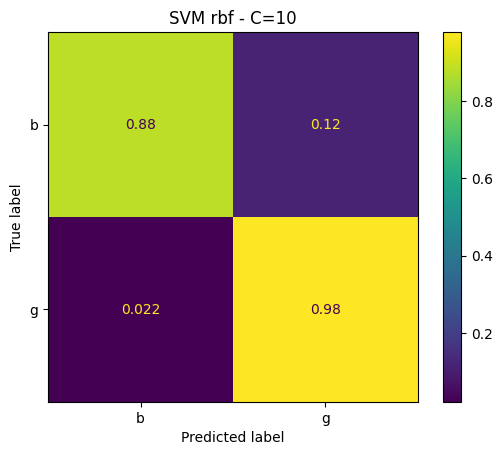

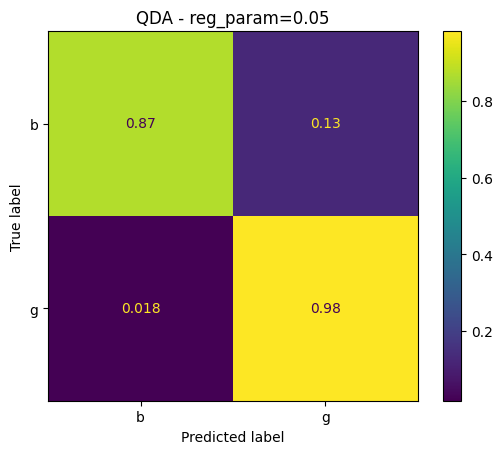

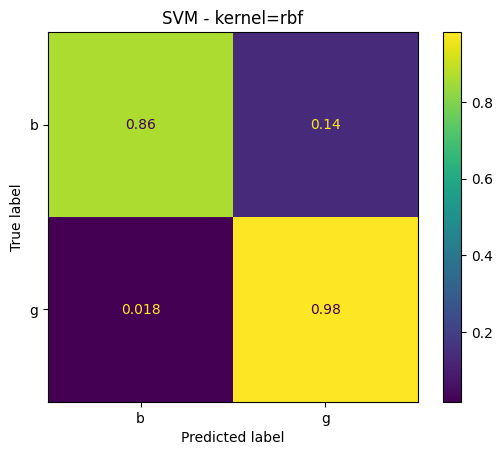

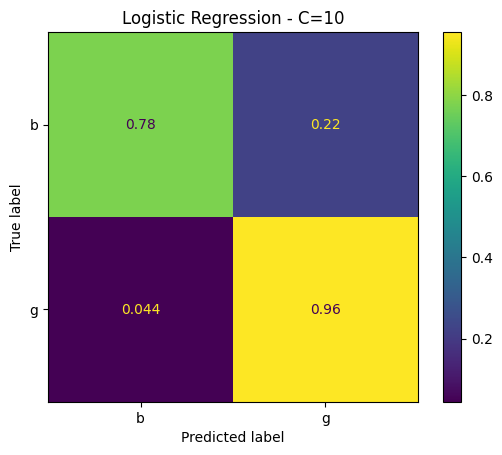

In [ ]:
# mostro le matrici di confusione dei migliori modelli.
# la matrice di confusione fa vedere dove il modello sbaglia:
# b predetti come g, oppure g predetti come b.
top = best_by_model.head(4) #primi 4 modelli migliori

for row in top.to_dict("records"): #ogni riga è un dizionario
    key = (row["model"], row["param_name"], str(row["param_value"])) #la chiave sarà una tupla con il nome del modello, il nome del parametro e il valore del parametro
    cm = cms[key]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot()
    plt.title(f"{row['model']} - {row['param_name']}={row['param_value']}")
    plt.show()

Le matrici di confusione mostrano come vengono distribuite le predizioni corrette
e gli errori per ciascuna classe. I valori sulla diagonale rappresentano le
classificazioni corrette, mentre quelli fuori diagonale rappresentano gli errori.
Nei modelli migliori la diagonale ha valori alti, quindi la maggior parte degli
esempi viene classificata correttamente.

# Discussione critica

Il dataset contiene 351 esempi e 34 attributi continui. La classe non e'
perfettamente bilanciata: ci sono 225 esempi `g` e 126 esempi `b`. Per questo
motivo e' stata usata una validazione `StratifiedKFold` a 5 fold, in modo da
mantenere una proporzione simile delle classi in ogni fold.

Dall'analisi esplorativa emerge che `attr_2` e' costante, quindi non porta
informazione utile alla classificazione. Per questo viene eliminata prima di
addestrare i modelli.

Il miglior risultato medio e' ottenuto da **SVM rbf** con
`C=10`, con accuracy media pari a
**94.31%**. Anche QDA con una piccola regolarizzazione
ottiene un risultato molto vicino. Questo e' coerente con il fatto che i
modelli non lineari riescono a descrivere meglio la separazione tra le due
classi.

Poiché il dataset non è perfettamente bilanciato, oltre all'accuracy sono state
calcolate anche precision e recall con media macro. Queste metriche danno
un'informazione aggiuntiva perché considerano entrambe le classi allo stesso
modo. I risultati confermano comunque quanto visto con l'accuracy: SVM RBF e QDA
regolarizzato restano i modelli migliori.


I modelli lineari, come regressione logistica, LDA e perceptron, funzionano ma
hanno performance inferiori. La SVM con kernel RBF supera la SVM lineare:
questo suggerisce che il problema non sia separabile in modo puramente lineare.

Lo studio dei parametri mostra che:

- nella regressione logistica il parametro `C` modifica la regolarizzazione;
- nella SVM il kernel e il parametro `C` influenzano molto le prestazioni;
- in QDA il parametro `reg_param` e' importante per stabilizzare il modello;
- nel perceptron il learning rate `eta0` cambia i risultati, ma il modello
  resta meno competitivo rispetto a SVM RBF e QDA.

Migliori configurazioni per famiglia:

- SVM rbf: C=10, accuracy media=94.31%, sd (deviazione standard)=2.01%
- QDA: reg_param=0.05, accuracy media=94.30%, sd (deviazione standard)=1.29%
- SVM: kernel=rbf, accuracy media=94.01%, sd (deviazione standard)=2.47%
- Logistic Regression: C=10, accuracy media=89.16%, sd (deviazione standard)=4.85%
- LDA: shrinkage=auto, accuracy media=86.88%, sd (deviazione standard)=4.49%
- Perceptron: eta0=0.1, accuracy media=86.88%, sd (deviazione standard)=3.91%

Nel complesso, i grafici confermano quanto osservato nella tabella dei risultati:
i modelli non lineari, soprattutto SVM con kernel RBF e QDA regolarizzato,
riescono a descrivere meglio il dataset rispetto ai modelli lineari. La
cross-validation mostra inoltre che i risultati sono abbastanza stabili, in
particolare per QDA.

In conclusione, sceglierei come modello principale la SVM con kernel RBF,
perché raggiunge la migliore accuracy media. QDA regolarizzato resta comunque
una buona alternativa, perché ottiene risultati molto simili e leggermente più
stabili tra i fold.